<a href="https://colab.research.google.com/github/thanosleggis/Thesis/blob/main/notebooks%20/%CE%91%CE%BD%CF%84%CE%AF%CE%B3%CF%81%CE%B1%CF%86%CE%BF_EEGNetv4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- ΒΗΜΑ 1: Εγκατάσταση της βιβλιοθήκης Braindecode (Το "Hugging Face" των EEG) ---
!pip install braindecode

import os
import zipfile
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive
# Εισαγωγή του ΕΤΟΙΜΟΥ μοντέλου EEGNet
from braindecode.models import EEGNetv4

# --- ΒΗΜΑ 2: Προετοιμασία (ίδια με πριν για να βρούμε το αρχείο) ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Έλεγχος πού είναι το zip
zip_paths = ['/content/DREAMER.zip', '/content/drive/MyDrive/DREAMER.zip']
target_zip = next((p for p in zip_paths if os.path.exists(p)), None)

if target_zip:
    extract_path = '/content/DREAMER_extracted'
    if not os.path.exists(extract_path):
        print("⏳ Αποσυμπίεση...")
        with zipfile.ZipFile(target_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

    # Εύρεση του .mat
    mat_path = None
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.mat') and 'DREAMER' in file:
                mat_path = os.path.join(root, file)
                break
        if mat_path: break
else:
    print("❌ Δεν βρέθηκε το DREAMER.zip. Ανέβασέ το!")
    mat_path = None

# --- ΒΗΜΑ 3: Φόρτωση Δεδομένων (Robust Loader) ---
def load_dreamer_ready(path):
    if not path: return None, None
    print(f"🔄 Φόρτωση δεδομένων για το EEGNet...")
    try:
        raw = sio.loadmat(path)
        data_struct = raw['DREAMER'][0, 0]['Data']
        X_list, y_list = [], []

        # Παράμετροι για EEGNet
        # Το EEGNet θέλει συγκεκριμένο μήκος, ας πούμε 128 (1 sec)
        window_size = 128

        for sub in range(23):
            try:
                # Δοκιμή για να βρούμε τα signals
                eeg_root = data_struct[0, sub]['EEG'][0, 0]
                if 'stimuli' in eeg_root.dtype.names:
                    stimuli = eeg_root['stimuli'][0, 0]
                else:
                    stimuli = eeg_root['Signals'][0, 0]
                valence = data_struct[0, sub]['ScoreValence'][0, 0]
            except: continue

            for trial in range(18):
                label = 1 if valence[trial, 0] >= 3 else 0
                signal = stimuli[trial, 0]

                # Sliding Window
                limit = min(len(signal), 128*30) # Παίρνουμε 30 δευτερόλεπτα max
                for start in range(0, limit - window_size, 64): # Step 64
                    seg = signal[start : start+window_size, :]
                    # Scaling (σημαντικό για το EEGNet)
                    seg = seg * 1e6 # Μετατροπή από Volts σε microVolts (σύνηθες στο Braindecode)
                    X_list.append(seg.T)
                    y_list.append(label)

        X = np.array(X_list, dtype=np.float32)
        # Το Braindecode θέλει (Batch, Channels, Time, 1) ή (Batch, Channels, Time)
        # Εμείς δίνουμε (Batch, Channels, Time)
        y = np.array(y_list, dtype=np.int64)
        print(f"✅ ΕΤΟΙΜΑ: {len(y)} δείγματα.")
        return torch.tensor(X), torch.tensor(y)
    except Exception as e:
        print(f"Error: {e}")
        return None, None

X_data, y_data = load_dreamer_ready(mat_path)

# --- ΒΗΜΑ 4: Χρήση του ΕΤΟΙΜΟΥ Μοντέλου EEGNet ---
if X_data is not None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Training EEGNet on {device}")

    # Φορτώνουμε το έτοιμο μοντέλο
    model = EEGNetv4(
        in_chans=14,        # 14 Κανάλια του DREAMER
        n_classes=2,        # 2 Κλάσεις (High/Low Valence)
        input_window_samples=128, # Μήκος παραθύρου
        final_conv_length='auto',
    ).to(device)

    # Εκπαίδευση
    optimizer = optim.Adam(model.parameters(), lr=0.01) # Το EEGNet θέλει λίγο μεγαλύτερο LR
    criterion = nn.CrossEntropyLoss()

    dataset = TensorDataset(X_data, y_data)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

    print("\n--- Ξεκινάει η εκπαίδευση του EEGNet ---")
    for epoch in range(15):
        model.train()
        correct = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == y).sum().item()

        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_val, y_val in test_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                out_val = model(X_val)
                val_correct += (out_val.argmax(1) == y_val).sum().item()

        print(f"Epoch {epoch+1:02d} | Train Acc: {correct/len(train_set):.2%} | Val Acc: {val_correct/len(test_set):.2%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Mounted at /content/dri

<decorator-gen-606>:4: FutureWarning: NOTE: EEGNetv4() is a deprecated class. `EEGNetv4` was renamed to `EEGNet` in v1.12; this alias will be removed in v1.14..


ValueError: n_times could not be inferred. Either specify n_times or input_window_seconds and sfreq.


🔌 Έλεγχος αρχείων...
📂 Αρχείο δεδομένων: /content/DREAMER_extracted/DREAMER.mat
🔄 Φόρτωση και επεξεργασία δεδομένων...
✅ ΕΤΟΙΜΑ: 36432 δείγματα. Shape: (36432, 14, 128)
🚀 Training EEGNet on cpu

--- Ξεκινάει η Εκπαίδευση ---
Epoch 01 | Loss: 0.6705 | Train Acc: 61.03% | Val Acc: 39.44%
Epoch 02 | Loss: 0.6652 | Train Acc: 61.03% | Val Acc: 60.79%
Epoch 03 | Loss: 0.6621 | Train Acc: 61.01% | Val Acc: 60.70%
Epoch 04 | Loss: 0.6592 | Train Acc: 60.83% | Val Acc: 58.83%
Epoch 05 | Loss: 0.6585 | Train Acc: 61.03% | Val Acc: 53.93%
Epoch 06 | Loss: 0.6574 | Train Acc: 61.24% | Val Acc: 59.31%
Epoch 07 | Loss: 0.6561 | Train Acc: 61.12% | Val Acc: 59.09%
Epoch 08 | Loss: 0.6555 | Train Acc: 61.13% | Val Acc: 51.50%
Epoch 09 | Loss: 0.6551 | Train Acc: 61.16% | Val Acc: 45.11%
Epoch 10 | Loss: 0.6544 | Train Acc: 61.02% | Val Acc: 61.07%
Epoch 11 | Loss: 0.6555 | Train Acc: 61.07% | Val Acc: 60.89%
Epoch 12 | Loss: 0.6546 | Train Acc: 61.40% | Val Acc: 60.89%
Epoch 13 | Loss: 0.6534 | Trai

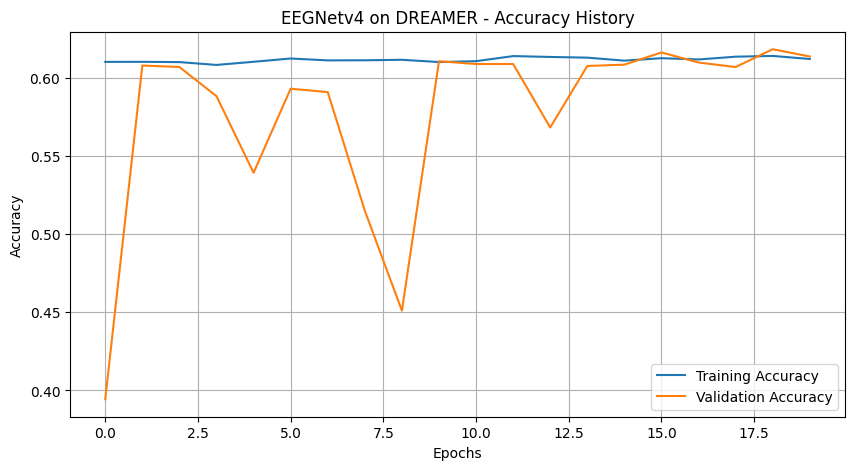


✅ Η διαδικασία ολοκληρώθηκε επιτυχώς!


In [ ]:
# --- ΒΗΜΑ 0: Εγκατάσταση Βιβλιοθηκών (αν δεν υπάρχουν) ---
try:
    import braindecode
except ImportError:
    print("⏳ Εγκατάσταση Braindecode & MNE...")
    !pip install -q braindecode mne

import os
import zipfile
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive
import matplotlib.pyplot as plt
from braindecode.models import EEGNetv4

# --- ΒΗΜΑ 1: Σύνδεση Drive & Εντοπισμός Αρχείου ---
print("\n🔌 Έλεγχος αρχείων...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Ψάχνουμε το zip σε Drive ή τοπικά
zip_paths = ['/content/DREAMER.zip', '/content/drive/MyDrive/DREAMER.zip']
target_zip = next((p for p in zip_paths if os.path.exists(p)), None)

if target_zip:
    extract_path = '/content/DREAMER_extracted'
    if not os.path.exists(extract_path):
        print("⏳ Αποσυμπίεση DREAMER.zip...")
        with zipfile.ZipFile(target_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

    # Εύρεση του .mat μέσα στον φάκελο
    mat_path = None
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.mat') and 'DREAMER' in file:
                mat_path = os.path.join(root, file)
                break
        if mat_path: break
    print(f"📂 Αρχείο δεδομένων: {mat_path}")
else:
    print("❌ ΣΦΑΛΜΑ: Δεν βρέθηκε το DREAMER.zip. Ανέβασέ το στα Files ή στο Drive!")
    mat_path = None

# --- ΒΗΜΑ 2: Φόρτωση Δεδομένων (Robust Loading) ---
def load_dreamer_eegnet(path):
    if not path: return None, None, None, None
    print(f"🔄 Φόρτωση και επεξεργασία δεδομένων...")

    try:
        raw = sio.loadmat(path)
        data_struct = raw['DREAMER'][0, 0]['Data']
        X_list, y_list = [], []

        # Ρυθμίσεις Παραθύρου
        window_size = 128  # 1 δευτερόλεπτο (στα 128Hz)
        step = 64          # Overlap 50%

        for sub in range(23):
            # Ανάκτηση δεδομένων (χειρισμός διαφορετικών ονομάτων keys)
            try:
                eeg_root = data_struct[0, sub]['EEG'][0, 0]
                if 'stimuli' in eeg_root.dtype.names:
                    stimuli = eeg_root['stimuli'][0, 0]
                else:
                    stimuli = eeg_root['Signals'][0, 0]
                valence = data_struct[0, sub]['ScoreValence'][0, 0]
            except: continue

            for trial in range(18):
                # Binary Classification: Low (<3) vs High (>=3) Valence
                label = 1 if valence[trial, 0] >= 3 else 0
                signal = stimuli[trial, 0] # (Time, 14)

                # Sliding Window Loop
                # Κόβουμε μέχρι 45 δευτερόλεπτα από κάθε βίντεο για να μην γεμίσει η RAM
                limit = min(len(signal), 128 * 45)

                for start in range(0, limit - window_size, step):
                    seg = signal[start : start+window_size, :]

                    # Scaling: Το EEGNet δουλεύει καλύτερα με microVolts (όχι Volts)
                    # Το DREAMER είναι συνήθως σε Volts, οπότε πολλαπλασιάζουμε με 1e6
                    seg = seg * 1e6

                    X_list.append(seg.T) # (Channels, Time)
                    y_list.append(label)

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int64)

        # Διαχωρισμός Train/Test (80% - 20%)
        # Προσθήκη διάστασης για το Braindecode αν χρειαστεί (εδώ το EEGNetv4 θέλει Chans x Time)
        print(f"✅ ΕΤΟΙΜΑ: {len(y)} δείγματα. Shape: {X.shape}")

        dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
        train_len = int(0.8 * len(dataset))
        test_len = len(dataset) - train_len
        train_set, test_set = torch.utils.data.random_split(dataset, [train_len, test_len])

        return train_set, test_set

    except Exception as e:
        print(f"❌ Error loading: {e}")
        return None, None

train_set, test_set = load_dreamer_eegnet(mat_path)

# --- ΒΗΜΑ 3: Εκπαίδευση EEGNet (GPU) ---
if train_set:
    # Set Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Training EEGNet on {device}")

    # DataLoaders
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

    # Μοντέλο: EEGNetv4 (ΔΙΟΡΘΩΜΕΝΟ API)
    model = EEGNetv4(
        n_chans=14,       # Κανάλια DREAMER
        n_outputs=2,      # Κλάσεις (High/Low)
        n_times=128,      # Samples (Window size)
        final_conv_length='auto'
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.005) # Λίγο χαμηλότερο LR για σταθερότητα
    criterion = nn.CrossEntropyLoss()

    # Λίστες για γραφήματα
    train_acc_history = []
    val_acc_history = []

    print("\n--- Ξεκινάει η Εκπαίδευση ---")
    for epoch in range(20): # 20 Epochs
        model.train()
        correct = 0
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            correct += (out.argmax(1) == y).sum().item()
            total_loss += loss.item()

        train_acc = correct / len(train_set)
        train_acc_history.append(train_acc)

        # Validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_val, y_val in test_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                out_val = model(X_val)
                val_correct += (out_val.argmax(1) == y_val).sum().item()

        val_acc = val_correct / len(test_set)
        val_acc_history.append(val_acc)

        print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2%} | Val Acc: {val_acc:.2%}")

    # --- ΒΗΜΑ 4: Γραφήματα Αποτελεσμάτων ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_history, label='Training Accuracy')
    plt.plot(val_acc_history, label='Validation Accuracy')
    plt.title('EEGNetv4 on DREAMER - Accuracy History')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\n✅ Η διαδικασία ολοκληρώθηκε επιτυχώς!")